# Sesquiterpene synthase classification

This notebook extends the active-site-based classification workflow developed for monoterpene synthases to linear and 1,6-cyclised sesquiterpene synthases. The model uses the 12 features selected for monoterpene synthases (FS1) and the same XGBoost hyperparameters, without further feature selection or hyperparameter optimisation.

The dataset contains 66 sesquiterpene synthases: 39 linear and 27 1,6-cyclised. Inverse-frequency class weights are calculated from the full dataset and applied during model training. Performance is assessed using a stratified holdout split and 10 repeats of stratified five-fold cross-validation. Cross-validation means and standard deviations are calculated across complete repeats.

Input: `sesquiterpene_data.csv`

Outputs: CSV summaries and figures are saved in `sesquiterpene_classification_results/`.

Dependencies: `pip install numpy pandas matplotlib scikit-learn xgboost shap`


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    log_loss,
    matthews_corrcoef,
    precision_recall_fscore_support,
)
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from xgboost import XGBClassifier

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


c:\Users\catha\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset and model configuration

Load the sesquiterpene dataset, select the 12 FS1 features, define the class labels and configure the XGBoost model. Calculate inverse-frequency sample weights from the full dataset.


In [2]:
DATASET_PATH = Path("sesquiterpene_data.csv")
OUTPUT_DIRECTORY = Path("sesquiterpene_classification_results")
RANDOM_STATE = 42
HOLDOUT_FRACTION = 0.20
N_SPLITS = 5
N_REPEATS = 10
CLASS_NAMES = {0: "Linear", 1: "1,6-cyclised"}
EXPECTED_CLASS_COUNTS = {0: 39, 1: 27}

SELECTED_FEATURES = [
    "Alanine - A",
    "Methionine - M",
    "Tryptophan - W",
    "Isoleucine - I",
    "Cysteine - C",
    "Histidine - H",
    "Asparagine - N",
    "Positive charge",
    "Negative charge",
    "Polar",
    "Non-polar",
    "Amino Acid based volume Score",
]

if not DATASET_PATH.is_file():
    raise FileNotFoundError(
        f"Cannot find the sesquiterpene dataset: {DATASET_PATH.resolve()}"
    )

data = pd.read_csv(DATASET_PATH)
required_columns = ["Protein", "Cyclical", *SELECTED_FEATURES]
missing_columns = [
    column for column in required_columns if column not in data.columns
]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

protein_ids = data["Protein"].astype(str)
y = pd.to_numeric(data["Cyclical"], errors="raise").astype(int)
X = data.loc[:, SELECTED_FEATURES].apply(pd.to_numeric, errors="raise")

if X.isna().any().any():
    missing_features = X.columns[X.isna().any()].tolist()
    raise ValueError(f"Selected features contain missing values: {missing_features}")

observed_class_counts = y.value_counts().sort_index().to_dict()
if observed_class_counts != EXPECTED_CLASS_COUNTS:
    raise ValueError(
        "Unexpected sesquiterpene dataset. "
        f"Expected class counts {EXPECTED_CLASS_COUNTS}, "
        f"found {observed_class_counts} in {DATASET_PATH.resolve()}."
    )

OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATASET_PATH.resolve()}")
print(f"Output directory: {OUTPUT_DIRECTORY.resolve()}")
print(f"Enzymes: {len(data)}")
print(f"Linear: {(y == 0).sum()}")
print(f"1,6-cyclised: {(y == 1).sum()}")
print(f"Selected FS1 features: {X.shape[1]}")


Dataset: F:\CDT MRes\DD\sesqterps\all_models\selected_pockets\sesquiterpene_data.csv
Output directory: F:\CDT MRes\DD\sesqterps\all_models\selected_pockets\sesquiterpene_classification_results
Enzymes: 66
Linear: 39
1,6-cyclised: 27
Selected FS1 features: 12


In [3]:
CLASS_WEIGHTS = {
    int(label): len(y) / int(count)
    for label, count in y.value_counts().items()
}
SAMPLE_WEIGHTS = y.map(CLASS_WEIGHTS)


def describe_training_weights(labels):
    labels = pd.Series(labels)
    summary = {}

    for label in [0, 1]:
        class_mask = labels.to_numpy() == label
        summary[f"{CLASS_NAMES[label]} training count"] = int(class_mask.sum())
        summary[f"{CLASS_NAMES[label]} sample weight"] = CLASS_WEIGHTS[label]

    return summary


def make_model():
    return XGBClassifier(
        objective="binary:logistic",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        tree_method="hist",
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        reg_alpha=0.1,
        reg_lambda=1.0,
        verbosity=0,
    )


def calculate_metrics(y_true, y_pred, cyclic_probability):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    cyclic_probability = np.asarray(cyclic_probability, dtype=float)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[0, 1],
        zero_division=0,
    )

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Matthews correlation coefficient": matthews_corrcoef(y_true, y_pred),
        "Log loss": log_loss(y_true, cyclic_probability, labels=[0, 1]),
        "Linear precision": precision[0],
        "Linear recall": recall[0],
        "Linear specificity": recall[1],
        "Linear F1": f1[0],
        "1,6-cyclised precision": precision[1],
        "1,6-cyclised recall": recall[1],
        "1,6-cyclised specificity": recall[0],
        "1,6-cyclised F1": f1[1],
    }


def format_metric(metric_name, value):
    if metric_name in {"Matthews correlation coefficient", "Log loss"}:
        return f"{value:.3f}"
    return f"{100 * value:.1f}%"


print("Full-dataset class weights:")
for name, value in describe_training_weights(y).items():
    print(f"  {name}: {value:.4f}" if "weight" in name else f"  {name}: {value}")


Full-dataset class weights:
  Linear training count: 39
  Linear sample weight: 1.6923
  1,6-cyclised training count: 27
  1,6-cyclised sample weight: 2.4444


## Exploratory stratified holdout evaluation

Evaluate the classifier using a single stratified 80:20 train-test split. Save the holdout metrics and individual enzyme predictions.


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=HOLDOUT_FRACTION,
    stratify=y,
    random_state=RANDOM_STATE,
)

holdout_model = make_model()
holdout_model.fit(
    X_train,
    y_train,
    sample_weight=SAMPLE_WEIGHTS.loc[y_train.index].to_numpy(),
)

holdout_pred = holdout_model.predict(X_test)
holdout_probability = holdout_model.predict_proba(X_test)[:, 1]

holdout_metrics = (
    pd.Series(calculate_metrics(y_test, holdout_pred, holdout_probability))
    .rename_axis("Metric")
    .to_frame("Score")
)
holdout_metrics.to_csv(OUTPUT_DIRECTORY / "holdout_metrics.csv")

holdout_predictions = pd.DataFrame({
    "Protein": protein_ids.loc[X_test.index].to_numpy(),
    "Observed class": y_test.map(CLASS_NAMES).to_numpy(),
    "Predicted class": pd.Series(holdout_pred).map(CLASS_NAMES).to_numpy(),
    "1,6-cyclised probability": holdout_probability,
    "Correct": holdout_pred == y_test.to_numpy(),
}).sort_values("Protein", ignore_index=True)
holdout_predictions.to_csv(
    OUTPUT_DIRECTORY / "holdout_predictions.csv",
    index=False,
)

print(f"Training enzymes: {len(X_train)}")
print(
    f"Test enzymes: {len(X_test)} "
    f"({(y_test == 0).sum()} linear, {(y_test == 1).sum()} 1,6-cyclised)"
)
print("Holdout training weights:")
for name, value in describe_training_weights(y_train).items():
    print(f"  {name}: {value:.4f}" if "weight" in name else f"  {name}: {value}")

holdout_metrics.round(4)


Training enzymes: 52
Test enzymes: 14 (8 linear, 6 1,6-cyclised)
Holdout training weights:
  Linear training count: 31
  Linear sample weight: 1.6923
  1,6-cyclised training count: 21
  1,6-cyclised sample weight: 2.4444


,Score
Metric,
Accuracy,0.9286
Balanced accuracy,0.9167
Matthews correlation coefficient,0.8607
Log loss,0.3609
Linear precision,0.8889
Linear recall,1.0000
Linear specificity,0.8333
Linear F1,0.9412
"1,6-cyclised precision",1.0000


## Repeated stratified five-fold cross-validation

Run 10 repeats of stratified five-fold cross-validation. Save fold-level predictions, complete-repeat performance metrics and recurrent misclassifications.


In [5]:
cross_validation = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

fold_records = []
prediction_records = []
raw_gain_records = []
normalized_gain_records = []
shap_values_by_fold = []
shap_feature_values_by_fold = []
shap_base_values_by_fold = []
shap_identity_records = []

for split_number, (train_index, validation_index) in enumerate(
    cross_validation.split(X, y)
):
    repeat = split_number // N_SPLITS + 1
    fold = split_number % N_SPLITS + 1

    X_fold_train = X.iloc[train_index]
    X_fold_valid = X.iloc[validation_index]
    y_fold_train = y.iloc[train_index]
    y_fold_valid = y.iloc[validation_index]

    model = make_model()
    model.fit(
        X_fold_train,
        y_fold_train,
        sample_weight=SAMPLE_WEIGHTS.iloc[train_index].to_numpy(),
    )

    predicted = model.predict(X_fold_valid)
    cyclic_probability = model.predict_proba(X_fold_valid)[:, 1]

    fold_records.append({
        "Repeat": repeat,
        "Fold": fold,
        **describe_training_weights(y_fold_train),
        **calculate_metrics(y_fold_valid, predicted, cyclic_probability),
    })

    prediction_records.extend({
        "Protein": protein_ids.iloc[index],
        "Repeat": repeat,
        "Fold": fold,
        "Observed": int(observed),
        "Predicted": int(prediction),
        "1,6-cyclised probability": float(probability),
        "Correct": bool(observed == prediction),
    } for index, observed, prediction, probability in zip(
        validation_index,
        y_fold_valid,
        predicted,
        cyclic_probability,
    ))

    fold_gain = pd.Series(
        model.get_booster().get_score(importance_type="gain"),
        dtype=float,
    ).reindex(SELECTED_FEATURES, fill_value=0.0)
    raw_gain_records.append({"Repeat": repeat, "Fold": fold, **fold_gain.to_dict()})

    total_gain = float(fold_gain.sum())
    normalized_gain = fold_gain / total_gain if total_gain else fold_gain
    normalized_gain_records.append({
        "Repeat": repeat,
        "Fold": fold,
        **normalized_gain.to_dict(),
    })

    explanation = shap.TreeExplainer(model)(X_fold_valid)
    shap_values_by_fold.append(np.asarray(explanation.values))
    shap_feature_values_by_fold.append(X_fold_valid.to_numpy())

    base_values = np.asarray(explanation.base_values)
    if base_values.ndim == 0:
        base_values = np.repeat(base_values, len(X_fold_valid))
    shap_base_values_by_fold.append(base_values)

    shap_identity_records.extend({
        "Protein": protein_ids.iloc[index],
        "Repeat": repeat,
        "Fold": fold,
    } for index in validation_index)

    if fold == N_SPLITS:
        print(f"Completed repeat {repeat}/{N_REPEATS}")

fold_metrics = pd.DataFrame(fold_records)
cv_predictions = pd.DataFrame(prediction_records)

fold_metrics.to_csv(OUTPUT_DIRECTORY / "cross_validation_fold_metrics.csv", index=False)
cv_predictions.to_csv(OUTPUT_DIRECTORY / "cross_validation_predictions.csv", index=False)

print(f"Cross-validation: {N_SPLITS} folds x {N_REPEATS} repeats")
print(f"Out-of-fold predictions: {len(cv_predictions)}")


Completed repeat 1/10
Completed repeat 2/10
Completed repeat 3/10
Completed repeat 4/10
Completed repeat 5/10
Completed repeat 6/10
Completed repeat 7/10
Completed repeat 8/10
Completed repeat 9/10
Completed repeat 10/10
Cross-validation: 5 folds x 10 repeats
Out-of-fold predictions: 660


In [6]:
fold_accuracy_table = (
    fold_metrics
    .pivot(index="Repeat", columns="Fold", values="Accuracy")
    .mul(100)
    .round(1)
)

fold_accuracy_table.columns = [
    f"Fold {fold}" for fold in fold_accuracy_table.columns
]

fold_accuracy_table["Repeat accuracy"] = (
    cv_predictions.groupby("Repeat")["Correct"].mean().mul(100).round(1)
)

fold_accuracy_table.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_fold_accuracy_table.csv"
)

print(
    f"Individual fold accuracies (%) across "
    f"{N_REPEATS} repeats and {N_SPLITS} stratified folds:"
)

fold_accuracy_table


Individual fold accuracies (%) across 10 repeats and 5 stratified folds:


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Repeat accuracy
Repeat,,,,,,
1,78.6,69.2,76.9,84.6,92.3,80.3
2,92.9,61.5,100.0,84.6,92.3,86.4
3,85.7,69.2,69.2,92.3,92.3,81.8
4,85.7,84.6,92.3,53.8,76.9,78.8
5,100.0,69.2,76.9,76.9,100.0,84.8
6,92.9,84.6,92.3,92.3,92.3,90.9
7,71.4,84.6,92.3,84.6,92.3,84.8
8,92.9,92.3,84.6,61.5,76.9,81.8
9,92.9,76.9,84.6,92.3,100.0,89.4


In [7]:
repeat_records = []

for repeat, group in cv_predictions.groupby("Repeat", sort=True):
    if len(group) != len(data):
        raise ValueError(
            f"Repeat {repeat} contains {len(group)} predictions, "
            f"but expected {len(data)}."
        )

    repeat_records.append({
        "Repeat": int(repeat),
        **calculate_metrics(
            group["Observed"],
            group["Predicted"],
            group["1,6-cyclised probability"],
        ),
    })

repeat_metrics = pd.DataFrame(repeat_records).set_index("Repeat")
cv_summary = (
    repeat_metrics.agg(["mean", "std"])
    .T.rename(columns={"mean": "Mean", "std": "Standard deviation"})
)

repeat_metrics.to_csv(OUTPUT_DIRECTORY / "cross_validation_repeat_metrics.csv")
cv_summary.to_csv(OUTPUT_DIRECTORY / "cross_validation_metric_summary.csv")

print(f"Repeated cross-validation results across {N_REPEATS} complete repeats:")
for metric_name, values in cv_summary.iterrows():
    mean = format_metric(metric_name, values["Mean"])
    standard_deviation = format_metric(metric_name, values["Standard deviation"])
    print(f"  {metric_name}: {mean} (SD {standard_deviation})")

cv_summary.round(4)


Repeated cross-validation results across 10 complete repeats:
  Accuracy: 84.4% (SD 3.8%)
  Balanced accuracy: 84.1% (SD 4.0%)
  Matthews correlation coefficient: 0.680 (SD 0.079)
  Log loss: 0.324 (SD 0.059)
  Linear precision: 87.7% (SD 3.7%)
  Linear recall: 85.6% (SD 3.9%)
  Linear specificity: 82.6% (SD 5.5%)
  Linear F1: 86.6% (SD 3.3%)
  1,6-cyclised precision: 80.0% (SD 4.7%)
  1,6-cyclised recall: 82.6% (SD 5.5%)
  1,6-cyclised specificity: 85.6% (SD 3.9%)
  1,6-cyclised F1: 81.2% (SD 4.6%)


,Mean,Standard deviation
Accuracy,0.8439,0.0385
Balanced accuracy,0.8412,0.0400
Matthews correlation coefficient,0.6798,0.0788
Log loss,0.3237,0.0589
Linear precision,0.8772,0.0368
Linear recall,0.8564,0.0386
Linear specificity,0.8259,0.0553
Linear F1,0.8663,0.0334
"1,6-cyclised precision",0.8002,0.0474
"1,6-cyclised recall",0.8259,0.0553


In [8]:
misclassified = cv_predictions.loc[~cv_predictions["Correct"]].copy()
misclassified["Predicted class probability"] = np.where(
    misclassified["Predicted"].eq(1),
    misclassified["1,6-cyclised probability"],
    1 - misclassified["1,6-cyclised probability"],
)

misclassification_summary = (
    misclassified.assign(
        **{"Observed class": misclassified["Observed"].map(CLASS_NAMES)}
    )
    .groupby(["Protein", "Observed class"], as_index=False)
    .agg(**{
        "Misclassifications": ("Predicted", "size"),
        "Mean incorrect prediction probability": (
            "Predicted class probability",
            "mean",
        ),
    })
    .sort_values(
        ["Misclassifications", "Protein"],
        ascending=[False, True],
        ignore_index=True,
    )
)

misclassification_summary.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_misclassifications.csv",
    index=False,
)

misclassification_summary.round(4)


,Protein,Observed class,Misclassifications,Mean incorrect prediction probability
0,F8TWD2_L,Linear,10,0.8163
1,G5CV41_3_1,Linear,9,0.7715
2,D8RNZ9_M_1_1,Linear,8,0.7954
3,J7LH11_3,"1,6-cyclised",8,0.7884
4,E3W205_1,"1,6-cyclised",7,0.7421
5,Q9T0K1_5,"1,6-cyclised",7,0.6620
6,A0A1J0CQ93_1,Linear,6,0.6846
7,A0A1J0CQ94_1,Linear,6,0.6918
8,J3MQP7_1,"1,6-cyclised",6,0.6584
9,Q66PX9_1,Linear,6,0.7432


## Repeated cross-validation confusion matrix

Summarise class-wise predictions across complete cross-validation repeats. Matrix values show the mean within-class percentage and standard deviation.


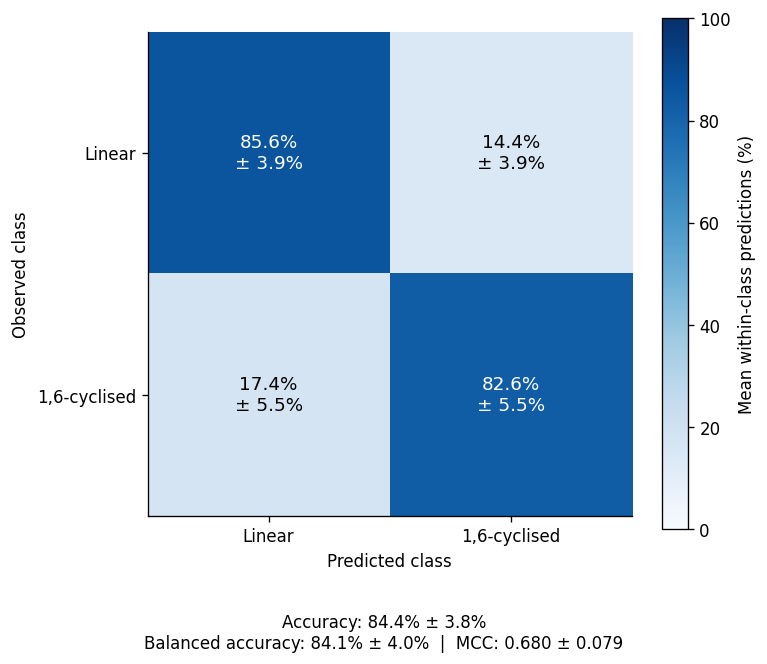

In [9]:
confusion_records = []
repeat_row_percentages = []

for repeat, group in cv_predictions.groupby("Repeat", sort=True):
    matrix = confusion_matrix(
        group["Observed"],
        group["Predicted"],
        labels=[0, 1],
    )
    row_percentages = matrix / matrix.sum(axis=1, keepdims=True) * 100
    repeat_row_percentages.append(row_percentages)

    for observed in [0, 1]:
        for predicted in [0, 1]:
            confusion_records.append({
                "Repeat": int(repeat),
                "Observed class": CLASS_NAMES[observed],
                "Predicted class": CLASS_NAMES[predicted],
                "Count": int(matrix[observed, predicted]),
                "Within-class percentage": float(
                    row_percentages[observed, predicted]
                ),
            })

confusion_by_repeat = pd.DataFrame(confusion_records)
confusion_by_repeat.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_confusion_by_repeat.csv",
    index=False,
)

mean_percentages = np.mean(repeat_row_percentages, axis=0)
standard_deviations = np.std(repeat_row_percentages, axis=0, ddof=1)

fig, ax = plt.subplots(figsize=(6.5, 5.6))
image = ax.imshow(mean_percentages, cmap="Blues", vmin=0, vmax=100)

for observed in [0, 1]:
    for predicted in [0, 1]:
        ax.text(
            predicted,
            observed,
            (
                f"{mean_percentages[observed, predicted]:.1f}%\n"
                f"± {standard_deviations[observed, predicted]:.1f}%"
            ),
            ha="center",
            va="center",
            fontsize=11,
            color="white" if mean_percentages[observed, predicted] >= 55 else "black",
        )

class_labels = [CLASS_NAMES[0], CLASS_NAMES[1]]
ax.set_xticks([0, 1], labels=class_labels)
ax.set_yticks([0, 1], labels=class_labels)
ax.set_xlabel("Predicted class")
ax.set_ylabel("Observed class")
fig.colorbar(image, ax=ax, label="Mean within-class predictions (%)")

accuracy = cv_summary.loc["Accuracy"]
balanced_accuracy = cv_summary.loc["Balanced accuracy"]
mcc = cv_summary.loc["Matthews correlation coefficient"]
footer = (
    f"Accuracy: {100 * accuracy['Mean']:.1f}% "
    f"± {100 * accuracy['Standard deviation']:.1f}%\n"
    f"Balanced accuracy: {100 * balanced_accuracy['Mean']:.1f}% "
    f"± {100 * balanced_accuracy['Standard deviation']:.1f}%  |  "
    f"MCC: {mcc['Mean']:.3f} ± {mcc['Standard deviation']:.3f}"
)
fig.text(0.5, 0.02, footer, ha="center", va="bottom", fontsize=10)
fig.tight_layout(rect=[0, 0.12, 1, 1])
fig.savefig(
    OUTPUT_DIRECTORY / "sesquiterpene_confusion_matrix.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()


## XGBoost feature importance

Summarise raw and normalised feature gain across cross-validation folds and plot the mean raw gain for each feature.


In [10]:
raw_gain_by_fold = pd.DataFrame(raw_gain_records)
normalized_gain_by_fold = pd.DataFrame(normalized_gain_records)

raw_gain_by_fold.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_feature_gain_by_fold.csv",
    index=False,
)
normalized_gain_by_fold.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_normalized_gain_by_fold.csv",
    index=False,
)

gain_summary = pd.DataFrame({
    "Feature": SELECTED_FEATURES,
    "Mean gain": raw_gain_by_fold[SELECTED_FEATURES].mean().to_numpy(),
    "Gain standard deviation": raw_gain_by_fold[SELECTED_FEATURES].std().to_numpy(),
    "Mean normalized gain": (
        normalized_gain_by_fold[SELECTED_FEATURES].mean().to_numpy()
    ),
    "Normalized gain standard deviation": (
        normalized_gain_by_fold[SELECTED_FEATURES].std().to_numpy()
    ),
}).sort_values("Mean gain", ascending=False, ignore_index=True)

gain_summary.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_feature_gain_summary.csv",
    index=False,
)

gain_summary.round(4)


,Feature,Mean gain,Gain standard deviation,Mean normalized gain,Normalized gain standard deviation
0,Cysteine - C,4.6607,1.0244,0.2765,0.0566
1,Positive charge,3.1941,0.6427,0.1902,0.0378
2,Asparagine - N,2.2960,0.8364,0.1385,0.0557
3,Histidine - H,0.9687,0.6928,0.0562,0.0376
4,Tryptophan - W,0.9085,0.6826,0.0535,0.0390
5,Amino Acid based volume Score,0.8773,0.3127,0.0525,0.0191
6,Negative charge,0.7989,0.5733,0.0468,0.0319
7,Polar,0.7899,0.4023,0.0472,0.0247
8,Alanine - A,0.7822,0.3032,0.0464,0.0174
9,Non-polar,0.7110,0.3222,0.0420,0.0183


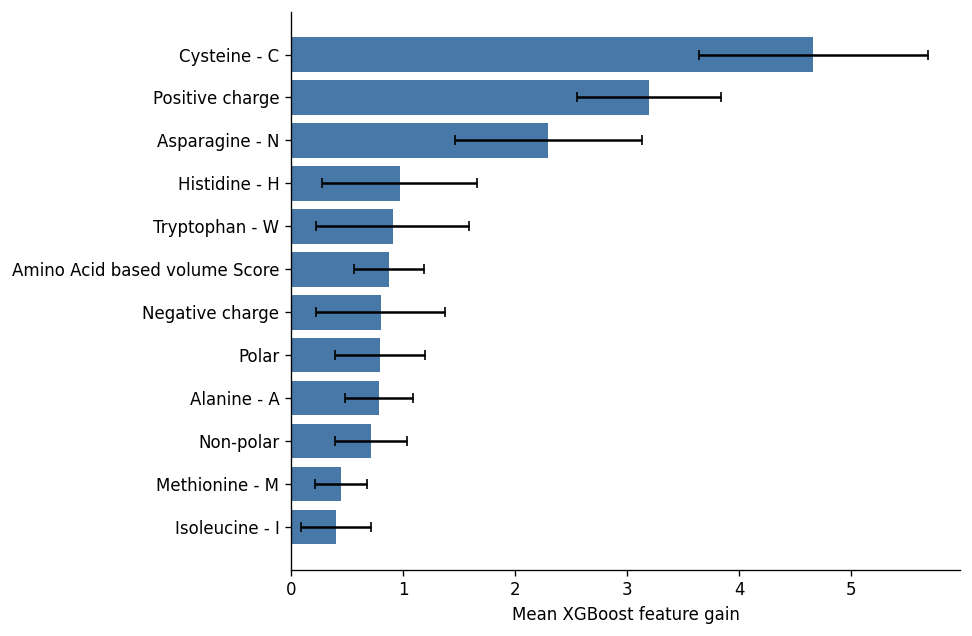

In [11]:
plot_gain = gain_summary.iloc[::-1]
gain_values = plot_gain["Mean gain"].to_numpy()
gain_standard_deviations = plot_gain["Gain standard deviation"].to_numpy()
error_bars = np.vstack([
    np.minimum(gain_values, gain_standard_deviations),
    gain_standard_deviations,
])

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.barh(
    plot_gain["Feature"],
    gain_values,
    xerr=error_bars,
    color="#4878A8",
    capsize=3,
)
ax.set_xlabel("Mean XGBoost feature gain")
ax.set_xlim(left=0)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIRECTORY / "sesquiterpene_feature_gain.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()


## Out-of-fold SHAP feature importance

Calculate SHAP values for held-out observations from each cross-validation fold and generate feature-importance and beeswarm plots.


In [12]:
out_of_fold_shap = shap.Explanation(
    values=np.vstack(shap_values_by_fold),
    base_values=np.concatenate(shap_base_values_by_fold),
    data=np.vstack(shap_feature_values_by_fold),
    feature_names=SELECTED_FEATURES,
)

shap_importance = pd.DataFrame({
    "Feature": SELECTED_FEATURES,
    "Mean absolute SHAP value": np.abs(out_of_fold_shap.values).mean(axis=0),
    "Absolute SHAP standard deviation": np.abs(
        out_of_fold_shap.values
    ).std(axis=0, ddof=1),
}).sort_values(
    "Mean absolute SHAP value",
    ascending=False,
    ignore_index=True,
)

shap_importance.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_shap_summary.csv",
    index=False,
)

shap_observations = pd.concat([
    pd.DataFrame(shap_identity_records),
    pd.DataFrame(
        out_of_fold_shap.values,
        columns=[f"SHAP: {feature}" for feature in SELECTED_FEATURES],
    ),
], axis=1)
shap_observations.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_shap_by_observation.csv",
    index=False,
)

print(f"Out-of-fold SHAP observations: {len(out_of_fold_shap.values)}")
shap_importance.round(4)


Out-of-fold SHAP observations: 660


,Feature,Mean absolute SHAP value,Absolute SHAP standard deviation
0,Cysteine - C,1.4507,0.6784
1,Positive charge,1.1410,0.7713
2,Asparagine - N,0.8313,0.5789
3,Alanine - A,0.6551,0.4243
4,Histidine - H,0.4166,0.3301
5,Polar,0.3956,0.3105
6,Non-polar,0.3770,0.2537
7,Amino Acid based volume Score,0.3087,0.2482
8,Methionine - M,0.2274,0.1773
9,Isoleucine - I,0.0646,0.0869


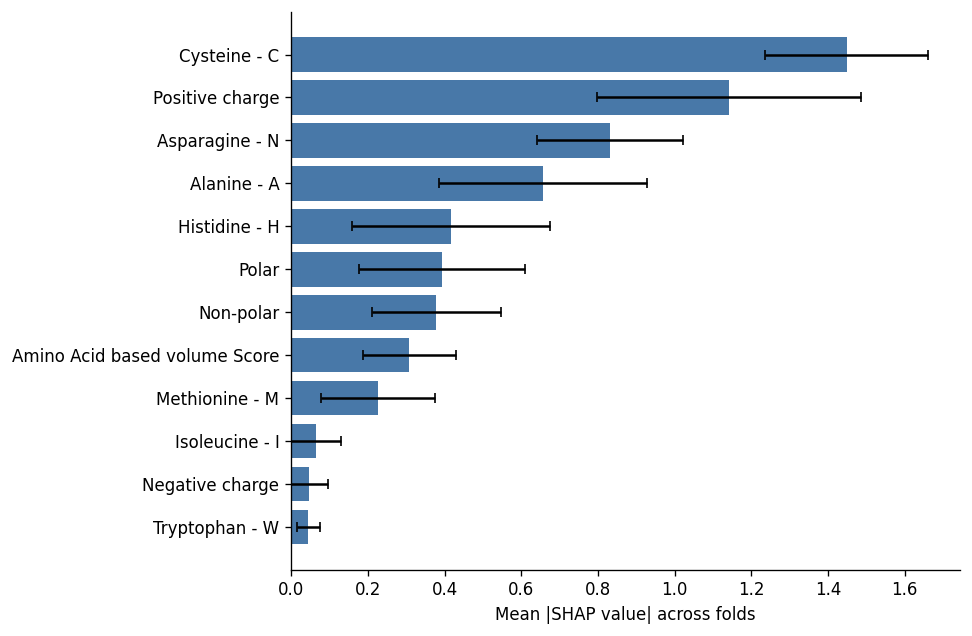

In [13]:
shap_by_fold = pd.DataFrame(
    [
        np.abs(fold_values).mean(axis=0)
        for fold_values in shap_values_by_fold
    ],
    columns=SELECTED_FEATURES,
)

shap_plot_summary = pd.DataFrame({
    "Feature": SELECTED_FEATURES,
    "Mean absolute SHAP": shap_by_fold.mean().to_numpy(),
    "Standard deviation": shap_by_fold.std().to_numpy(),
}).sort_values("Mean absolute SHAP", ascending=True)

shap_plot_summary.to_csv(
    OUTPUT_DIRECTORY / "cross_validation_shap_fold_summary.csv",
    index=False,
)

means = shap_plot_summary["Mean absolute SHAP"].to_numpy()
standard_deviations = shap_plot_summary["Standard deviation"].to_numpy()
error_bars = np.vstack([
    np.minimum(means, standard_deviations),
    standard_deviations,
])

fig, ax = plt.subplots(figsize=(8.2, 5.4))
ax.barh(
    shap_plot_summary["Feature"],
    means,
    xerr=error_bars,
    color="#4878A8",
    capsize=3,
)
ax.set_xlabel("Mean |SHAP value| across folds")
ax.set_xlim(left=0)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIRECTORY / "sesquiterpene_shap_importance.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()


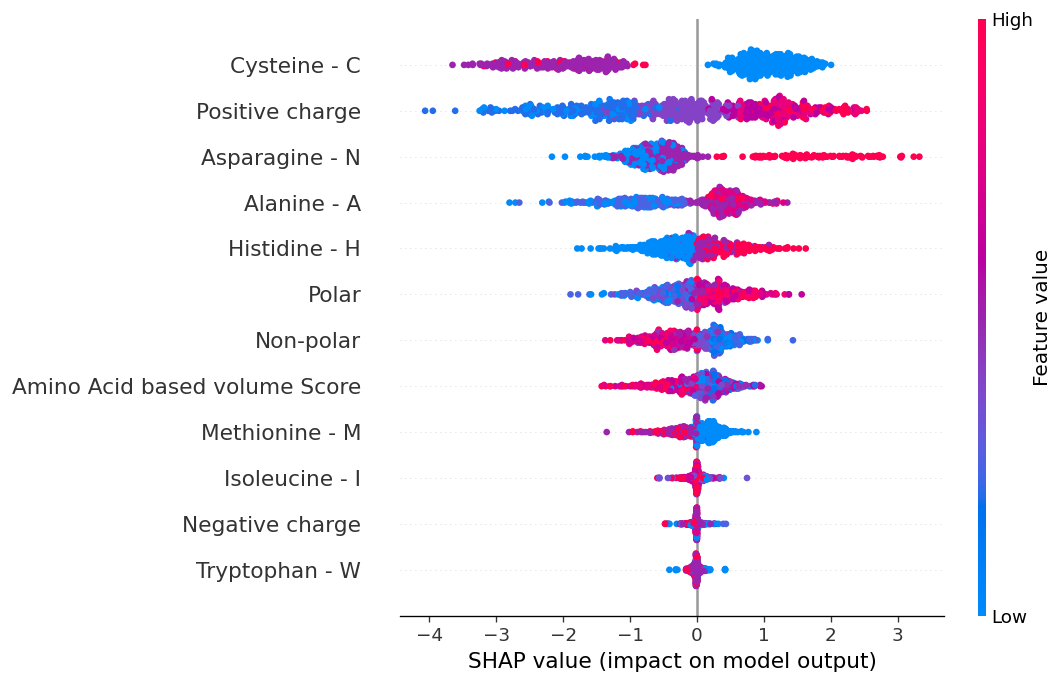

All CSV files and figures saved to: F:\CDT MRes\DD\sesqterps\all_models\selected_pockets\sesquiterpene_classification_results


In [14]:
shap.plots.beeswarm(
    out_of_fold_shap,
    max_display=len(SELECTED_FEATURES),
    show=False,
)
plt.gcf().set_size_inches(9.2, 5.8)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIRECTORY / "sesquiterpene_shap_beeswarm.png",
    dpi=600,
    bbox_inches="tight",
)
plt.show()

print(f"All CSV files and figures saved to: {OUTPUT_DIRECTORY.resolve()}")
